In [ ]:
import psycopg2
import pandas as pd

def connect_db():
    connect = psycopg2.connect(
        host = "localhost",
        database = "DBM_Group 0",
        user = "postgres",
        password = "storm123"
)
    
    return connect

**Function 1 - Call content related characteristics and their respective box_office**

In [2]:
def movie_bo (): #make it easy to call the overlapping movies in movie and box_office dataset
    connect = connect_db() #open the database connection defined above
    cur = connect.cursor() #create cursor to run SQL

#execute cursor function
#select title and runtime from movie
#rating from rating table joined by the matching rating ids between movie and rating table
#box office from box_office table joined by the matching urls between movie and box_office tables
    cur.execute(""" 
        select
            movie.title,
            movie.runtime,
            rating.rating_name,
            box_office.worldwide_box_office
        from movie
        join rating
            on movie.rating_id = rating.rating_id
        join box_office
            on movie.url = box_office.movie_url;
    """)

    rows = cur.fetchall() #store all rows as rows

    columns = [
        "title",
        "runtime",
        "rating",
        "worldwide_box_office"
    ] #define column names for dataframe

    df = pd.DataFrame(rows, columns=columns)

    cur.close()
    connect.close()

    return df

In [3]:
df = movie_bo()
df.head()

,title,runtime,rating,worldwide_box_office
0,10 Years,100.0,R,987640.0
1,360,110.0,R,4141251.0
2,44 Inch Chest,95.0,R,NaN
3,Annapolis,108.0,PG-13,17224992.0
4,"10,000 km",99.0,R,20452.0


**Function 2 - Call genre and box_office relation**

In [41]:
def genre_box_office (): #Function for calling the genre per movie and its corresponding box_office
    connect = connect_db() #open the database connection defined above
    cur = connect.cursor() #create cursor to run SQL

#execute cursor function
#select the movie title from movie
#select the genre name from genre
#select worldwide_box_office from box_office
#match movie records with their box_office data using URL
#join the junction table between movie and genre
#join with genre on genre_id   

    cur.execute(""" 
        select
            movie.title,                        
            genre.genre_name,                   
            box_office.worldwide_box_office     
        from movie
        join box_office                         
            on movie.url = box_office.movie_url
        join movie_genre                        
            on movie.url = movie_genre.url
        join genre                               
            on movie_genre.genre_id = genre.genre_id;
    """)

    rows = cur.fetchall() #store all rows as rows

    columns = [
        "title",
        "genre",
        "worldwide_box_office"
    ] #define column names for dataframe

    df = pd.DataFrame(rows, columns=columns)

    cur.close()
    connect.close()

    return df

In [42]:
df2 = genre_box_office()
df2.head()

,title,genre,worldwide_box_office
0,10 Years,Drama,987640.0
1,10 Years,Comedy,987640.0
2,10 Years,Romance,987640.0
3,360,Drama,4141251.0
4,360,Romance,4141251.0


**Genre specific analysis**

Text(0, 0.5, 'Worldwide box office (x $100.000.000)')

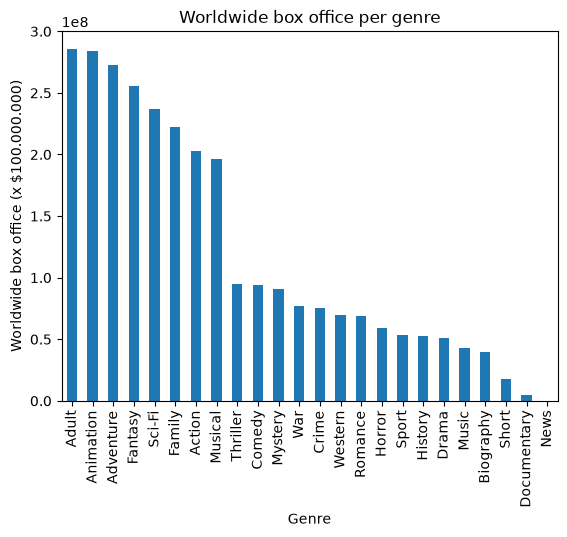

In [ ]:
import matplotlib.pyplot as plt

df_genre = genre_box_office()

genre_average = (
    df_genre.groupby("genre")["worldwide_box_office"].mean().sort_values(ascending= False)
)
genre_median = (
    df_genre.groupby("genre")["worldwide_box_office"].median().sort_values(ascending= False)
)

genre_average.plot(
    kind = "bar",
)

plt.title("Worldwide box office per genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Worldwide box office (x $100.000.000)")
plt.show()


genre_average.plot(
    kind = "bar",
)

plt.title("Worldwide box office per genre")
plt.suptitle("")
plt.xlabel("Genre")
plt.ylabel("Worldwide box office (x $100.000.000)")
plt.show()
